---
title: "Probability for the Data Scientist"
---

In [3]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Continuous Real Valued Random Variables in One Dimension

Understanding that there is no way to explain probability in full, let's make sure we have some fundamentals in place.  To wit, we begin with the idea of a continuous, real-valued random variable, say $X$, with a corresponding *probability distribution* $p(x)$ so that the probability of $a\leq X \leq b$, say $\mathbb{P}(a\leq X \leq b)$ is given by
> $\mathbb{P}(a\leq X \leq b) = \int_{a}^{b}p(x)dx$.

The distribution $p(x)$ is defined so that $p(x)\geq 0$ and 
$$
\int_{-\infty}^{\infty}p(x)dx = 1,
$$
which says that $\mathbb{P}(-\infty\leq X \leq \infty)=1$, i.e. the real-valued random variable $X$ takes on some real value with probability 1.  

Affiliated with this are the definitions of *average* and *variance*.  
> The average, say $\mathbb{E}\left[X\right]$, of a continuous, real-valued random variable $X$ is 
$$
\mathbb{E}\left[X\right] = \int_{-\infty}^{\infty}xp(x)dx
$$
> The variance, say $\mathbb{V}(X)$, of a continuous, real-valued random variable $X$ is 

\begin{align*}
\mathbb{V}(X) = & \mathbb{E}\left[(X-\mathbb{E}[X])^{2}\right] \\
= & \int_{-\infty}^{\infty}\left(x-\mathbb{E}[X]\right)^{2}p(x)dx\\
= & \int_{-\infty}^{\infty}\left(x^{2}-2x\mathbb{E}[X] + \left(\mathbb{E}[X]\right)^{2}\right)p(x)dx\\
= & \mathbb{E}[X^{2}]-\left(\mathbb{E}[X]\right)^{2}
\end{align*}

*Problem*: Fill in the last step of the above derivation for the variance.  

*Problem*: For a Gaussian random variable $X$, we have 
$$
p(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^{2}/2\sigma^{2}}.
$$
Show that 
$$
\mathbb{E}[X] = \mu, ~ \mathbb{V}[X] = \sigma^{2}.
$$

Using $\mu$ and $\sigma$ as shorthand variables for the average and variance is typical throughout probability theory, and we follow this convention as well.  Looking at different choices of $\mu$ and $\sigma$ (see below) help us understand how the classic "bell" curve shifts its center according to $\mu$ and changes its width and height via $\sigma$.

Text(0.5, 1.0, 'Gaussian Distributions for Varying $\\mu$ and $\\sigma$.')

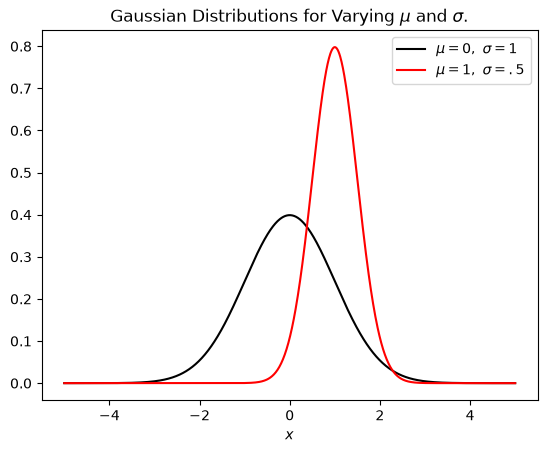

In [12]:
pgauss = lambda x, mu, sigma: (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

xvals = np.linspace(-5,5,1001)

plt.plot(xvals, pgauss(xvals, 0, 1),c='k', label=r'$\mu = 0, ~ \sigma=1$')
plt.plot(xvals, pgauss(xvals, 1, .5),c='r', label=r'$\mu = 1, ~ \sigma=.5$')

plt.xlabel('$x$')
plt.legend()
plt.title(r'Gaussian Distributions for Varying $\mu$ and $\sigma$.')

## Continuous Random Variables in Two Dimensions

So, the moment we make more than one measurement, we enter the realm of multi-dimensional probability.  I don't write the rules; this is just how it goes.  For example, if I take two random measurements, we can think of there being two random variables, $X_1$ and $X_2$.  A natural way to think about this is that you are measuring a random process (or a noisy one anyway) at two different moments in time.  You can also imagine things happening at the same time, but along different axes (say I measure pressure and temperature of the surrounding air).  The power of such abstract frameworks is their versatility, but of course, it can feel challenging to bring things back to Earth as it were.  

Anyway, properly, our two measurements are fully described by a joint distribution $p(x_1,x_2)$ so that 

> $\mathbb{P}\left(a\leq X_1\leq b, c\leq X_2\leq d\right) = \int_{a}^{b}\int_{c}^{d}p(x_{1},x_{2})dx_{2}dx_{1}$.

This of course feels categorically unfair.  Why should simply being curious about more than one thing by necessity invoke some of the most dreaded realsm within Calculus?  Yet so it goes.  Further, from this we can define *marginal* distributions along each direction, say $p(x)$ and $p(y)$ where

$$
p(x_{1}) = \int_{-\infty}^{\infty}p(x_{1},x_{2})dx_{2}, ~ p(x_{2}) = \int_{-\infty}^{\infty}p(x_{1},x_{2})dx_{1}.
$$

Likewise, everything from above gets a multi-dimensional upgrade.  We now have a vector average, say $\mathbb{E}[{\bf X}] = \boldsymbol{\mu}\in\mathbb{R}^{2}$, where if our random vector ${\bf X} = (X_{1} ~X_{2})^{T}$, then 

$$
\mu_{1} = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}x_{1}p(x_{1},x_{2})dx_{2} dx_{1}, ~ \mu_{2} = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}x_{2} p(x_{1},x_{2})dx_{2} dx_{1}.
$$

Using the marginal distributions above, we can of course also naturally define $\mathbb{E}[X]$ and $\mathbb{E}[Y]$ where
$$
\mathbb{E}[X_{1}] = \mu_{1} = \int_{-\infty}^{\infty}x_{1}p(x_{1})dx_{1}, ~ \mathbb{E}[X_{2}] = \mu_{2} = \int_{-\infty}^{\infty}x_{2}p(x_{2})dx_{2}.
$$

What gets weirder is that variance doesn't just extend along dimension in a one-by-one fashion.  Instead, we get a matrix $\mathbb{V}({\bf X})$ where we have the standard notion of variance along each dimension

$$
\mathbb{V}({\bf X})_{11} = \mathbb{E}[(X_{1}-\mu_{1})^{2}], ~ \mathbb{V}({\bf X})_{22} = \mathbb{E}[(X_{2}-\mu_{2})^{2}]
$$

but then we also need to check the co-variance across dimensions so that 

$$
\mathbb{V}({\bf X})_{12} = \mathbb{V}({\bf X})_{21} = \mathbb{E}[(X_{1}-\mu_{1})(X_{2}-\mu_{2})].
$$

*Problem*: Show that $\mathbb{V}({\bf X}) = \mathbb{E}[({\bf X}-\boldsymbol{\mu})({\bf X}-\boldsymbol{\mu})^{T}]$, and thus that it is a positive definite matrix.   

*Problem*: If for square matrices ${\bf A}$ and ${\bf B}$ we generally have that 
$$
\text{det}(AB) = \text{det}(A)\text{det}(B),
$$
and $\text{det}(A)=\text{det}(A^{T})$, show that for an orthogonal matrix ${\bf O}$ that 
$$
\left|\text{det}({\bf O}) \right| = 1.
$$

*Problem*: More generally, if ${\bf A}$ is an invertible matrix, show that 
$$
\text{det}({\bf A}^{-1}) = \frac{1}{\text{det}({\bf A})}.
$$

Following on this problem, we also need to remember how changes of variables work in multi-dimensional integrals.  We'll try to keep this as basic and to the point as possible.  To wit, if we have an invertible linear transformation ${\bf L}:\mathbb{R}^{2}\rightarrow \mathbb{R}^{2}$, then if we are integrating over some "nice" area $A\subset \mathbb{R}^{2}$, integrals change coordinates according to the following formula: 
$$
\int_{A}f({\bf L}{\bf x})d{\bf x} = \frac{1}{\left|\text{det}({\bf L})\right|}\int_{{\bf L}(A)}f({\bf y})d{\bf y}, ~ {\bf y} = {\bf L}{\bf x}.
$$
<div align=center>
<img src="./area_transformation.png" width="500" alt="My Chart">
</div>

*Problem*: We define a two-dimensional Gaussian random variable ${\bf X}$ via the distribution

$$
p({\bf x}) = ce^{-\frac{1}{2}\left<({\bf x}-\boldsymbol{\mu}),{\bf C}^{-1}({\bf x}-\boldsymbol{\mu})\right>}
$$

where $c\in\mathbb{R}$ is a *normalization constant* so that 

$$
c \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}e^{-\frac{1}{2}\left<({\bf x}-\boldsymbol{\mu}),{\bf C}^{-1}({\bf x}-\boldsymbol{\mu})\right>}dx_{2}dx_{1} = 1,
$$

and $\boldsymbol{\mu}\in\mathbb{R}^{2}$ and ${\bf C}$ is a positive definite $2\times 2$ matrix.  Using the spectral decomposition of positive definite ${\bf C}$ so that 
$$
{\bf C} = {\bf U}\boldsymbol{\Sigma}^{2}{\bf U}^{T}, ~ \boldsymbol{\Sigma}^{2} = \begin{pmatrix}\sigma^{2}_{1} & 0 \\ 0 & \sigma_{2}^{2}\end{pmatrix},
$$
show that the normalization constant $c$ is given by 
$$
c = \frac{1}{2\pi \text{det}\left(\boldsymbol{\Sigma}\right)} = \frac{1}{2\pi \sqrt{\text{det}({\bf C})}}.
$$

*Problem*: Following this, show that for the 2-d Gaussian that 
$$
\mathbb{E}[{\bf X}] = \boldsymbol{\mu}, ~ \mathbb{V}({\bf X}) = {\bf C}.
$$

*Problem*: Show that if we have $n$ Gaussian random variables then 
$$
c = \frac{1}{\sqrt{(2\pi)^{n}\text{det}({\bf C})}}.
$$

## Independance, Correlation, and Conditional Probability

A central question in probability is whether two random variables are coupled in a statistically meaningful way.  We measure this via the notion of *independance*.

> Two random variables $X_{1}$ and $X_{2}$ are independent if $p(X_{1},X_{2})=p(X_{1})p(X_{2})$.  

*Problem*: Show that if $X_{1}$ and $X_{2}$ are random variables with means $\mu_{1}$ and $\mu_{2}$ that if they are independent then
$$
\mathbb{E}[(X_{1}-\mu_{1})(X_{2}-\mu_{2})] = 0.
$$

*Problem*: Show that if $\left\{X_{j}\right\}_{j=1}^{N_{d}}$ are independent Gaussian random variables with identical means and variances then ${\bf C} = \sigma^{2}{\bf I}$.  

From the prior problem, we see that independence prevents covariance or what we also call *correlation* between random variables.  Equivalently, we see that independence makes $\mathbb{V}$ diagonal.  In turn, the degree of correlation between random variables quantifies the extent to which they depend on one another.  So on the one hand, repeating experiments should produce independent outcomes unless we allow contamination from one test to the next.  On the other hand, random processes in time could have correlation due to underlying physics or some foundational dynamical system which drives evolution in time.  

In contrast then to independence, we can ask how much does the probability of one random varaible change if I give you information about another.  This leads to the notion of *conditional* distributions where if I tell you that $X_{2}=c$, then define the conditional probability on $X_{1}$, say $p(\left.X_{1}\right| X_{2}=c)$, via the formula 

> $p(\left.x_{1}\right| X_{2}=c) = \frac{p(x_{1},c)}{p(c)}$ where $p(c)=\int_{-\infty}^{\infty}p(x_{1},c)dx_{1}$.

*Problem*: Show that $\int_{-\infty}^{\infty}p(x_{1}|X_{2}=c)dx_{1} = 1$.

*Problem*: Show that if $X_{1}$ and $X_{2}$ are independent then $p(\left.x_{1}\right| X_{2}=c) = p(x_{1})$.

*Problem* Show that $p(x_{1}|x_{2})p(x_{2}) = p(x_{2}|x_{1})p(x_{1})$.  

This last identity turns out to be absurdly useful in what is called Bayesian analysis.  

### Maximum Likelihood Estimation and Data Science

So, first off, following our discussion of Gaussians from above, when we pass from 2 random variables to n random variables, not much from above changes aside from adding arrows or boldface to the type.  So in plural dimensions, if I have some collection of m-random variables in the vector ${\bf X}_{1}\in\mathbb{R}^{m}$ and some other collection in ${\bf X}_{2}$ then 
$$
p(\left.{\bf x}_{1}\right|{\bf X}_{2}={\bf c}) = \frac{p({\bf x}_{1},{\bf X}_{2}={\bf c})}{p({\bf X}_{2}={\bf c})}, ~ p({\bf X}_{2}={\bf c}) = \int_{\mathbb{R}^{m}}p({\bf x}_{1},{\bf c})d{\bf x}_{1}.
$$

Fine, but why do I need all of this?  Well, suppose I give you data in the form of vector pairs say $\left\{({\bf x}_{j},{\bf y}_{j}\right\}_{j=1}^{N_{d}}$, and I have some idea that ${\bf y}_{j}$ functionally depends on ${\bf x}_{j}$ but I don't really know how.  However, if I assume that ${\bf y}_{j}$ are independent, then I can use some parameter dependent probability function so that I can define $p(\left.{\bf y}_{j}\right|{\bf x}_{j},\boldsymbol{\theta})$ and then in turn define the total probability $p({\bf Y})$ via the formula 
$$
p({\bf Y}) = \prod_{j=1}^{N_{d}}p(\left.{\bf y}_{j}\right|{\bf x}_{j},\boldsymbol{\theta}).
$$
Taking logarithms, we can rewrite this as 
$$
\log p({\bf Y}) = \sum_{j=1}^{N_{d}}\log p(\left.{\bf y}_{j}\right|{\bf x}_{j},\boldsymbol{\theta})
$$
This function is called the *log likelihood*.  Given its centrality in data science, we introduce the standalone notation $\mathcal{L}(\boldsymbol{\theta})$ to denote it.  We close the loop by finding the maximum likelihood estimation (MLE) of the parameters, say $\boldsymbol{\theta}_{mle}$, via the formula
$$
\boldsymbol{\theta}_{mle} = \text{arg max}_{\boldsymbol{\theta}} \mathcal{L}(\boldsymbol{\theta}),
$$
where again
$$
\mathcal{L}(\boldsymbol{\theta}) = \sum_{j=1}^{N_{d}}\log p(\left.{\bf y}_{j}\right|{\bf x}_{j},\boldsymbol{\theta}).
$$

Let's do an example. Suppose I give you independent Gauassian random variables $y_{j}\sim\mathcal{N}(\mu,\sigma^{2})$.  How would we estimate $\mu$ and $\sigma$?  If we follow the MLE approach from above, we have 
$$
\mathcal{L}(\mu,\sigma) = -\left( \frac{1}{2\sigma^{2}}\sum_{j=1}^{N_{d}}\left(y_{j} - \mu\right)^{2} + N_{d}\log(\sigma) + \frac{N_{d}}{2}\log(2\pi)\right).
$$
The minus sign is awkward here, so we let $\tilde{\mathcal{L}}(\mu,\sigma)=-\mathcal{L}(\mu,\sigma)$, and then get rid of it by flipping from a 'max' to a 'min', i.e., 
$$
(\mu_{mle},\sigma_{mle}) = \text{arg min}_{(\mu, \sigma)} \tilde{\mathcal{L}}(\mu,\sigma).
$$
To find $\mu$ then, we solve
$$
\frac{\partial \tilde{\mathcal{L}}}{\partial \mu} = 0, 
$$
which then gets us the equation
$$
\frac{1}{2\sigma^{2}}\sum_{j=1}^{N_{d}}(y_{j}-\mu_{mle}) = 0.
$$

*Problem*: Assuming $\sigma\neq 0$, show that 
$$
\mu_{mle} = \frac{1}{N_{d}}\sum_{j=1}^{N_{d}}y_{j}.
$$

*Problem*: Show that 
$$
\sigma_{mle}^{2} = \frac{1}{N_{d}}\sum_{j=1}^{N_{d}}\left(y_{j}-\mu_{mle}\right)^{2}.
$$
